# Average Speed - LSTM

## Imports

In [1]:
import torch

import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

## Constants

In [2]:
DATASET_FILEPATH = '../data/v1/output_fcd.csv'

SEQUENCE_LENGTH = 30

BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_SIZE = 1
HIDDEN_SIZE = 50
FC_SIZE = 50
OUTPUT_SIZE = 1

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

## Load Data

In [3]:
data = pd.read_csv(DATASET_FILEPATH, sep=';')
data

,timestep_time,vehicle_angle,vehicle_id,vehicle_lane,vehicle_pos,vehicle_slope,vehicle_speed,vehicle_type,vehicle_x,vehicle_y
0,0.0,229.42,veh0,24913519#0_2,5.10,0.0,0.00,veh_passenger,1041.41,377.58
1,1.0,229.12,veh0,24913519#0_2,7.20,0.0,2.10,veh_passenger,1039.83,376.21
2,2.0,228.82,veh0,24913519#0_2,10.91,0.0,3.71,veh_passenger,1037.04,373.76
3,3.0,228.82,veh0,24913519#0_2,16.97,0.0,6.06,veh_passenger,1032.48,369.78
4,4.0,228.82,veh0,24913519#0_2,25.29,0.0,8.32,veh_passenger,1026.22,364.30
...,...,...,...,...,...,...,...,...,...,...
37330,7199.0,271.51,veh386,1217865061#0_0,18.39,0.0,12.71,veh_passenger,244.64,113.06
37331,7199.0,237.29,veh387,-339201177#5_0,28.87,0.0,2.31,veh_passenger,643.68,380.27
37332,7199.0,265.97,veh388,4611699#0_0,55.58,0.0,13.47,veh_passenger,548.79,129.65
37333,7199.0,265.47,veh389,1149417521#2_0,1.21,0.0,14.27,veh_passenger,388.25,116.80


## Feature Engineering

In [4]:
average_speed_per_timestep = data.groupby('timestep_time')['vehicle_speed'].mean().reset_index()
average_speed_per_timestep = average_speed_per_timestep.sort_values('timestep_time')
average_speed_per_timestep.columns = ['timestep_time', 'average_vehicle_speed']
average_speed_per_timestep

,timestep_time,average_vehicle_speed
0,0.0,0.000000
1,1.0,2.100000
2,2.0,3.710000
3,3.0,6.060000
4,4.0,8.320000
...,...,...
7195,7195.0,11.392222
7196,7196.0,11.504444
7197,7197.0,11.457778
7198,7198.0,11.282500


## Scaling

In [5]:
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(average_speed_per_timestep['average_vehicle_speed'].values.reshape(-1, 1))

## Sequence Generation

In [6]:
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data_normalized, SEQUENCE_LENGTH)

# Ensure that y has shape (num_samples, 1)
y = y.reshape(-1, 1)

## Train and Validation Split

In [7]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).float()

# Create DataLoaders for training and validation sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## LSTM Model

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, fc_size=25, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size

        # First LSTM layer (sequences)
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        # Second LSTM layer (output at the last timestep)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, fc_size)
        self.fc2 = nn.Linear(fc_size, output_size)
    
    def forward(self, x):
        # (batch_size, sequence_length, input_size)
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        # (batch_size, sequence_length, hidden_size)
        
        # Output at the last timestep
        out = out[:, -1, :]
        # (batch_size, hidden_size)
        out = self.fc1(out)
        # (batch_size, fc_size)
        out = self.fc2(out)
        # (batch_size, output_size)
        return out

In [9]:
# Initialize model, loss function, and optimizer
model = LSTMModel(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, fc_size=FC_SIZE, output_size=OUTPUT_SIZE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training

In [10]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, device):
    model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)
            
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {epoch_train_loss:.4f} - Validation Loss: {epoch_val_loss:.4f}")

    return train_losses, val_losses

In [11]:
train_losses, val_losses = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE
)

Epoch [1/20] - Training Loss: 0.0346 - Validation Loss: 0.0084
Epoch [2/20] - Training Loss: 0.0070 - Validation Loss: 0.0063
Epoch [3/20] - Training Loss: 0.0046 - Validation Loss: 0.0033
Epoch [4/20] - Training Loss: 0.0026 - Validation Loss: 0.0024
Epoch [5/20] - Training Loss: 0.0019 - Validation Loss: 0.0019
Epoch [6/20] - Training Loss: 0.0018 - Validation Loss: 0.0017
Epoch [7/20] - Training Loss: 0.0018 - Validation Loss: 0.0016
Epoch [8/20] - Training Loss: 0.0018 - Validation Loss: 0.0016
Epoch [9/20] - Training Loss: 0.0018 - Validation Loss: 0.0016
Epoch [10/20] - Training Loss: 0.0018 - Validation Loss: 0.0016
Epoch [11/20] - Training Loss: 0.0018 - Validation Loss: 0.0016
Epoch [12/20] - Training Loss: 0.0018 - Validation Loss: 0.0019
Epoch [13/20] - Training Loss: 0.0017 - Validation Loss: 0.0016
Epoch [14/20] - Training Loss: 0.0017 - Validation Loss: 0.0016
Epoch [15/20] - Training Loss: 0.0017 - Validation Loss: 0.0017
Epoch [16/20] - Training Loss: 0.0018 - Validatio

## Validation

In [12]:
def evaluate_model(model, val_loader, criterion, device):
    model.eval()
    predictions = []
    targets = []
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            predictions.append(outputs.cpu().numpy())
            targets.append(y_batch.cpu().numpy())

        mse = total_loss / len(val_loader.dataset)
        predictions = np.concatenate(predictions, axis=0)
        targets = np.concatenate(targets, axis=0)

        return mse, predictions, targets

In [13]:
mse, predictions, targets = evaluate_model(
    model=model,
    val_loader=val_loader,
    criterion=criterion,
    device=DEVICE
)

print(f"Mean Squared Error on Validation Set: {mse:.4f}")

predictions_inv = scaler.inverse_transform(predictions)
targets_inv = scaler.inverse_transform(targets)

Mean Squared Error on Validation Set: 0.0016


## Plotting

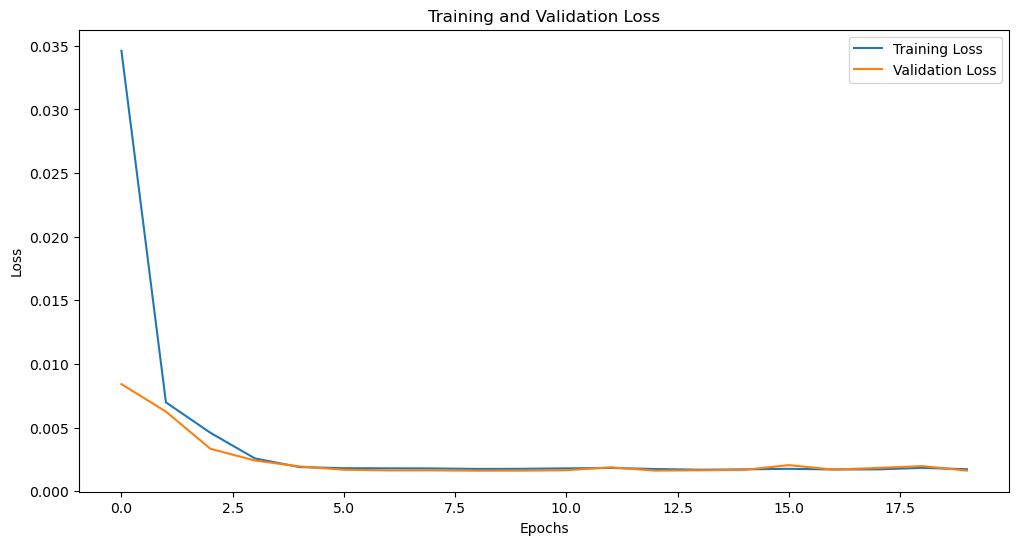

In [14]:
# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

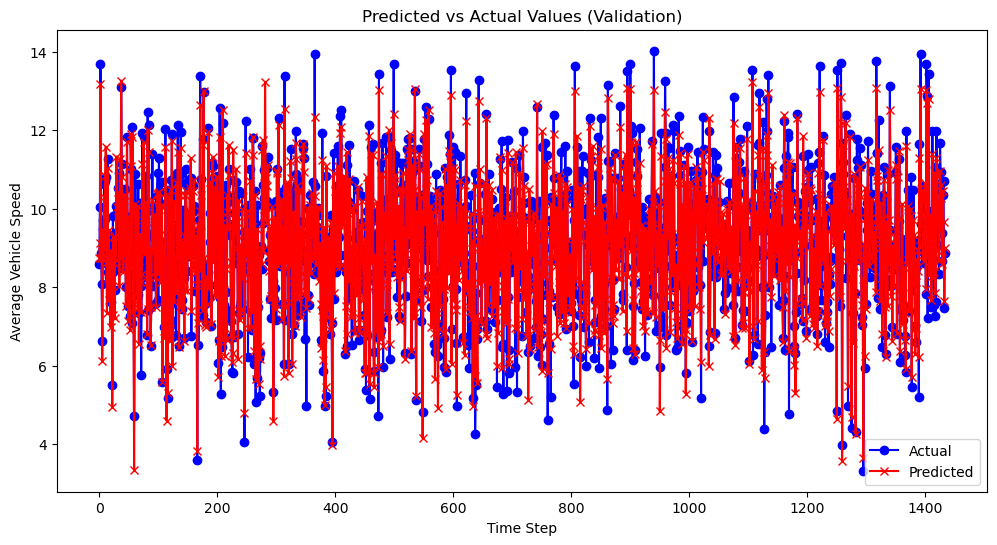

In [15]:
# Plot predicted vs actual values (Validation)
plt.figure(figsize=(12, 6))
plt.plot(range(len(targets_inv)), targets_inv, marker='o', linestyle='-', color='b', label='Actual')
plt.plot(range(len(predictions_inv)), predictions_inv, marker='x', linestyle='-', color='r', label='Predicted')
plt.title('Predicted vs Actual Values (Validation)')
plt.xlabel('Time Step')
plt.ylabel('Average Vehicle Speed')
plt.legend()
plt.show()

## Model 2

In [16]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train_2, X_test = X[:train_size], X[train_size:]
y_train_2, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train_2_tensor = torch.from_numpy(X_train_2).float()
y_train_2_tensor = torch.from_numpy(y_train_2).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

# Create DataLoaders for training and test sets
train_dataset_2 = TensorDataset(X_train_2_tensor, y_train_2_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader_2 = DataLoader(train_dataset_2, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
# Initialize model, loss function, and optimizer
model_2 = LSTMModel(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, fc_size=FC_SIZE, output_size=OUTPUT_SIZE)
criterion_2 = nn.MSELoss()
optimizer_2 = optim.Adam(model_2.parameters(), lr=LEARNING_RATE)

In [20]:
train_losses_2, val_losses_2 = train_model(
    model=model_2,
    criterion=criterion_2,
    optimizer=optimizer_2,
    train_loader=train_loader_2,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE
)

Epoch [1/20] - Training Loss: 0.0288 - Validation Loss: 0.0090
Epoch [2/20] - Training Loss: 0.0070 - Validation Loss: 0.0064
Epoch [3/20] - Training Loss: 0.0051 - Validation Loss: 0.0043
Epoch [4/20] - Training Loss: 0.0033 - Validation Loss: 0.0030
Epoch [5/20] - Training Loss: 0.0025 - Validation Loss: 0.0030
Epoch [6/20] - Training Loss: 0.0021 - Validation Loss: 0.0026
Epoch [7/20] - Training Loss: 0.0020 - Validation Loss: 0.0019
Epoch [8/20] - Training Loss: 0.0018 - Validation Loss: 0.0018
Epoch [9/20] - Training Loss: 0.0018 - Validation Loss: 0.0019
Epoch [10/20] - Training Loss: 0.0017 - Validation Loss: 0.0021
Epoch [11/20] - Training Loss: 0.0017 - Validation Loss: 0.0020
Epoch [12/20] - Training Loss: 0.0017 - Validation Loss: 0.0019
Epoch [13/20] - Training Loss: 0.0017 - Validation Loss: 0.0019
Epoch [14/20] - Training Loss: 0.0017 - Validation Loss: 0.0018
Epoch [15/20] - Training Loss: 0.0017 - Validation Loss: 0.0020
Epoch [16/20] - Training Loss: 0.0017 - Validatio

In [21]:
mse_2, predictions_2, targets_2 = evaluate_model(
    model=model_2,
    val_loader=test_loader,
    criterion=criterion_2,
    device=DEVICE
)

print(f"Mean Squared Error on Test Set: {mse_2:.4f}")

predictions_inv_2 = scaler.inverse_transform(predictions_2)
targets_inv_2 = scaler.inverse_transform(targets_2)

Mean Squared Error on Test Set: 0.0017


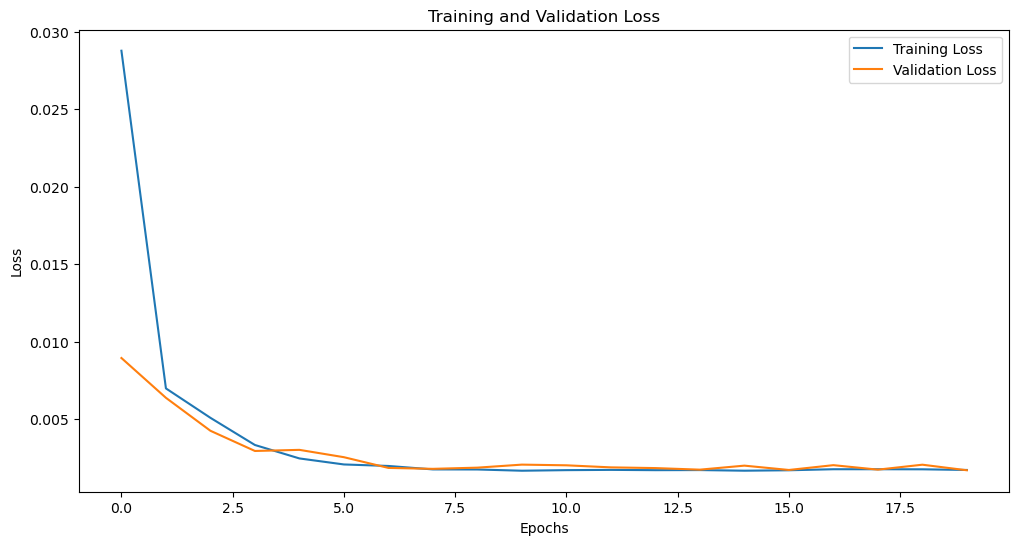

In [22]:
# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(train_losses_2, label='Training Loss')
plt.plot(val_losses_2, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

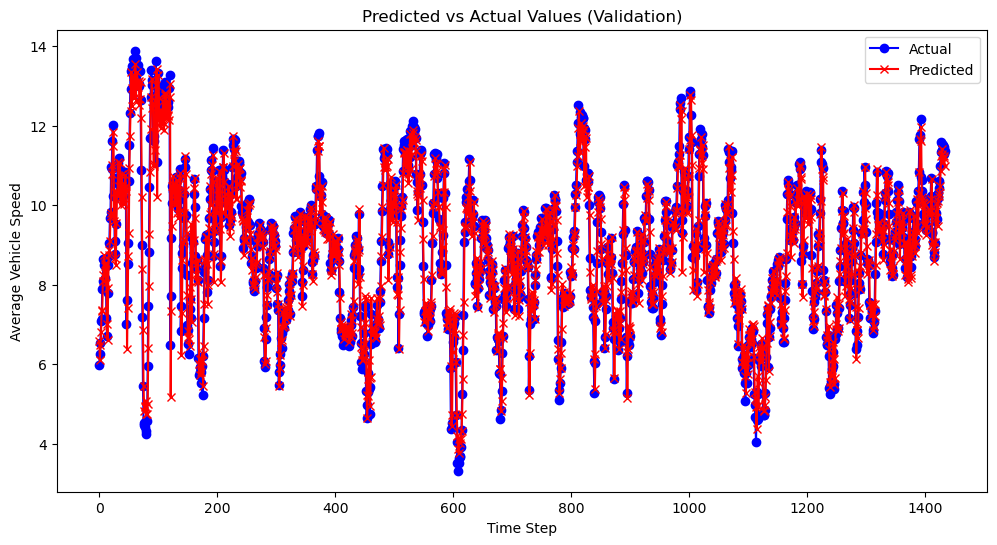

In [23]:
# Plot predicted vs actual values (Test)
plt.figure(figsize=(12, 6))
plt.plot(range(len(targets_inv_2)), targets_inv_2, marker='o', linestyle='-', color='b', label='Actual')
plt.plot(range(len(predictions_inv_2)), predictions_inv_2, marker='x', linestyle='-', color='r', label='Predicted')
plt.title('Predicted vs Actual Values (Validation)')
plt.xlabel('Time Step')
plt.ylabel('Average Vehicle Speed')
plt.legend()
plt.show()